In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("vipoooool/new-plant-diseases-dataset")

# print("Path to dataset files:", path)

In [3]:
import os 
import time
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import warnings
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG19
from sklearn.metrics import confusion_matrix, classification_report

warnings.filterwarnings('ignore')

2025-12-13 07:42:02.199428: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765611722.442085      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765611722.509458      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [4]:
BASE_PATH = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)'
train_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train'
valid_path = '/kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid'

In [5]:
NUM_CLASSES = 38
IMG_SIZE_224 = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15

print(f"Dataset Train Path: {train_path}")
print(f"Dataset Valid Path: {valid_path}")
print(f"Number of Classes: {NUM_CLASSES}")

Dataset Train Path: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Dataset Valid Path: /kaggle/input/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid
Number of Classes: 38


In [6]:
print("\nLoading Training Set...")
training_set = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels="inferred",
    label_mode="int", 
    image_size=IMG_SIZE_224,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)

total_batches = training_set.cardinality().numpy()
training_set = training_set.shuffle(
    buffer_size=100,
    reshuffle_each_iteration=True
)
portion = 0.5
training_set = training_set.take(int(total_batches * portion))
print(f"Training set loaded, using {int(total_batches * portion)} batches (50%).")

print("Loading Validation Set...")
validation_set = tf.keras.utils.image_dataset_from_directory(
    valid_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE_224,
    batch_size=BATCH_SIZE,
    color_mode="rgb",
    shuffle=True
)
print("Validation set loaded.")


Loading Training Set...
Found 70295 files belonging to 38 classes.


I0000 00:00:1765611762.266080      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765611762.266661      47 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Training set loaded, using 1098 batches (50%).
Loading Validation Set...
Found 17572 files belonging to 38 classes.
Validation set loaded.


In [7]:
base_vgg19 = VGG19(
    weights="imagenet", include_top=False, input_shape=IMG_SIZE_224 + (3,)
)
base_vgg19.trainable = False

vgg19 = tf.keras.models.Sequential([
    base_vgg19,
    layers.GlobalAveragePooling2D(), 
    layers.Dropout(0.3),
    layers.Dense(256, activation="relu"),
    layers.Dense(NUM_CLASSES, activation="softmax") 
])

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [8]:
vgg19.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("\n--- VGG19 Model Summary ---")
vgg19.summary() 


--- VGG19 Model Summary ---


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 7, 7, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,165,478 (76.93 MB)

 Trainable params: 141,094 (551.15 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [9]:
print(f"\nStarting training for {EPOCHS} epochs...")
start_time = time.time() 
training_history = vgg19.fit(
    x=training_set,
    validation_data=validation_set,
    epochs=EPOCHS
)
end_time = time.time() 
training_time = end_time - start_time
print(f"Training finished. Total time: {training_time:.2f} seconds.")


Starting training for 15 epochs...
Epoch 1/15


I0000 00:00:1765611774.662299     115 service.cc:148] XLA service 0x7c265c00e6e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765611774.663495     115 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765611774.663516     115 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765611775.102561     115 cuda_dnn.cc:529] Loaded cuDNN version 90300


   1/1098 ━━━━━━━━━━━━━━━━━━━━ 5:38:51 19s/step - accuracy: 0.0312 - loss: 9.7029

I0000 00:00:1765611786.243347     115 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1098/1098 ━━━━━━━━━━━━━━━━━━━━ 394s 342ms/step - accuracy: 0.5772 - loss: 1.7588 - val_accuracy: 0.8788 - val_loss: 0.3764
Epoch 2/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 393s 356ms/step - accuracy: 0.8419 - loss: 0.4998 - val_accuracy: 0.9198 - val_loss: 0.2355
Epoch 3/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 394s 357ms/step - accuracy: 0.8658 - loss: 0.4124 - val_accuracy: 0.9185 - val_loss: 0.2430
Epoch 4/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 393s 356ms/step - accuracy: 0.8737 - loss: 0.3753 - val_accuracy: 0.9238 - val_loss: 0.2267
Epoch 5/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 392s 355ms/step - accuracy: 0.8879 - loss: 0.3314 - val_accuracy: 0.9287 - val_loss: 0.2137
Epoch 6/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 392s 355ms/step - accuracy: 0.8920 - loss: 0.3216 - val_accuracy: 0.9339 - val_loss: 0.1995
Epoch 7/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 393s 356ms/step - accuracy: 0.8952 - loss: 0.3039 - val_accuracy: 0.9348 - val_loss: 0.2041
Epoch 8/15
1098/1098 ━━━━━━━━━━━━━━━━━━━━ 392s 355ms/step - accuracy: 0.9

In [10]:
MODEL_ID = "VGG19"
MODEL_SAVE_PATH = f"{MODEL_ID.lower()}_plant_disease_model.h5" 
try:
    vgg19.save(MODEL_SAVE_PATH)
    print(f"\n Model successfully saved as: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"\nError saving model: {e}")


 Model successfully saved as: vgg19_plant_disease_model.h5


In [11]:
train_loss, train_acc = vgg19.evaluate(training_set, verbose=0)
print(f'\nTraining accuracy: {train_acc:.4f}')

val_loss, val_acc = vgg19.evaluate(validation_set, verbose=0)
print(f'Validation accuracy: {val_acc:.4f}')


Training accuracy: 0.9684
Validation accuracy: 0.9386


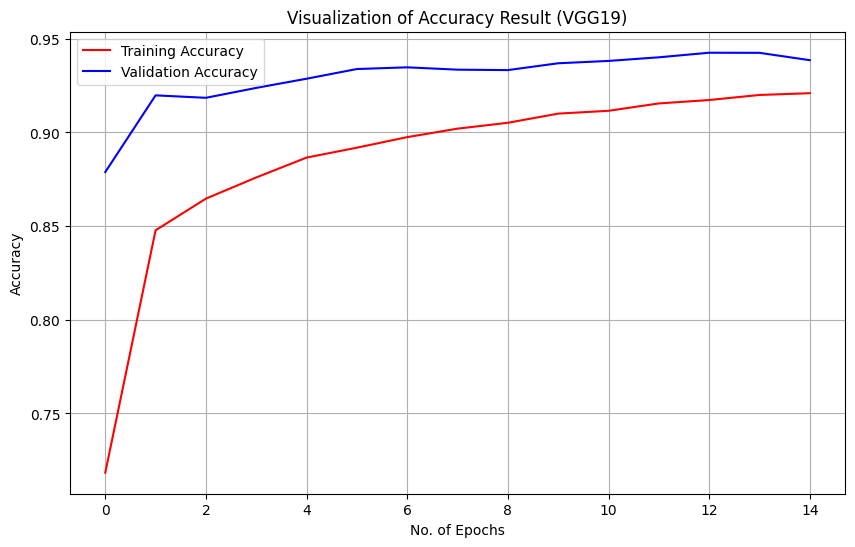

In [12]:
epochs_range = range(EPOCHS)
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, training_history.history['accuracy'], color='red', label='Training Accuracy')
plt.plot(epochs_range, training_history.history['val_accuracy'], color='blue', label='Validation Accuracy')
plt.xlabel('No. of Epochs')
plt.ylabel('Accuracy')
plt.title('Visualization of Accuracy Result (VGG19)')
plt.legend()
plt.grid(True)
plt.show()

In [13]:
class_name = validation_set.class_names
print("\n--- Preparing Test Set for Confusion Matrix ---")


test_set = tf.keras.utils.image_dataset_from_directory(
    valid_path, 
    labels="inferred",
    label_mode="int",
    color_mode="rgb",
    batch_size=1,
    image_size=IMG_SIZE_224,
    shuffle=False,
)


--- Preparing Test Set for Confusion Matrix ---
Found 17572 files belonging to 38 classes.


In [14]:
print("Generating predictions...")
y_pred = vgg19.predict(test_set, verbose=0)

true_categories = tf.concat([y for x, y in test_set], axis=0)
Y_true = true_categories.numpy()
predicted_categories = tf.argmax(y_pred, axis=1).numpy()

Generating predictions...


In [15]:
report = classification_report(Y_true, predicted_categories, target_names=class_name, output_dict=True)

print("\n--- Classification Report ---")
print(classification_report(Y_true, predicted_categories, target_names=class_name, digits=4))


--- Classification Report ---
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9665    0.9147    0.9399       504
                                 Apple___Black_rot     0.9367    0.9819    0.9587       497
                          Apple___Cedar_apple_rust     0.9742    0.9432    0.9584       440
                                   Apple___healthy     0.9387    0.9761    0.9570       502
                               Blueberry___healthy     0.9781    0.9824    0.9802       454
          Cherry_(including_sour)___Powdery_mildew     0.9836    0.9976    0.9906       421
                 Cherry_(including_sour)___healthy     0.9891    0.9956    0.9923       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9788    0.7878    0.8730       410
                       Corn_(maize)___Common_rust_     0.9979    0.9832    0.9905       477
               Corn_(maize)___Northern_Leaf_Blig

In [16]:
metrics_summary = {
    'Model': MODEL_ID,
    'Accuracy': report['accuracy'],
    'Precision (Wgt Avg)': report['weighted avg']['precision'], 
    'Recall (Wgt Avg)': report['weighted avg']['recall'],
    'F1-Score (Wgt Avg)': report['weighted avg']['f1-score'],
}

df_metrics = pd.DataFrame([metrics_summary])
results_file = 'model_performance_summary.csv'

In [17]:
if not os.path.exists(results_file):
    df_metrics.to_csv(results_file, index=False)
else:
    df_metrics.to_csv(results_file, mode='a', header=False, index=False)
    
print(f"\nMetrics successfully saved/appended to {results_file}")


Metrics successfully saved/appended to model_performance_summary.csv
